In [7]:
import pandas as pd

import numpy as np
from matplotlib import pyplot



In [3]:
#Carga del dataset
df = pd.read_csv('bike-sharing-demand/train.csv')

# Dimensiones generales
print(f"Filas:    {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

# Primeras 5 filas
print("\nPrimeras 5 filas:")
print(df.head())


Filas:    10886
Columnas: 12

Primeras 5 filas:
              datetime  season  holiday  workingday  weather  temp   atemp  \
0  2011-01-01 00:00:00       1        0           0        1  9.84  14.395   
1  2011-01-01 01:00:00       1        0           0        1  9.02  13.635   
2  2011-01-01 02:00:00       1        0           0        1  9.02  13.635   
3  2011-01-01 03:00:00       1        0           0        1  9.84  14.395   
4  2011-01-01 04:00:00       1        0           0        1  9.84  14.395   

   humidity  windspeed  casual  registered  count  
0        81        0.0       3          13     16  
1        80        0.0       8          32     40  
2        80        0.0       5          27     32  
3        75        0.0       3          10     13  
4        75        0.0       0           1      1  


In [4]:
# PREPROCESAMIENTIENTO DE DATOS
# Extraer la hora de datetime y renombrarla a hour
df['hour'] = pd.to_datetime(df['datetime']).dt.hour


df = df.drop(columns=['datetime', 'casual', 'registered'])

# Verificar resultado
print(f"Columnas después del preprocesamiento: {df.shape[1]}")
print(f"\nColumnas actuales:")
print(df.columns.tolist())
print(f"\nPrimeras 5 filas:")
print(df.head())

Columnas después del preprocesamiento: 10

Columnas actuales:
['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'count', 'hour']

Primeras 5 filas:
   season  holiday  workingday  weather  temp   atemp  humidity  windspeed  \
0       1        0           0        1  9.84  14.395        81        0.0   
1       1        0           0        1  9.02  13.635        80        0.0   
2       1        0           0        1  9.02  13.635        80        0.0   
3       1        0           0        1  9.84  14.395        75        0.0   
4       1        0           0        1  9.84  14.395        75        0.0   

   count  hour  
0     16     0  
1     40     1  
2     32     2  
3     13     3  
4      1     4  


In [6]:

# Separar características (X) y variable objetivo (y)
y = df['count'].values

# X = features (todo excepto count)
X = df.drop(columns=['count']).values

m, n = X.shape

# Verificar dimensiones
print(f"Ejemplos de entrenamiento (m): {m}")
print(f"Features (n):                  {n}")
print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")

Ejemplos de entrenamiento (m): 10886
Features (n):                  9
Dimensiones de X: (10886, 9)
Dimensiones de y: (10886,)


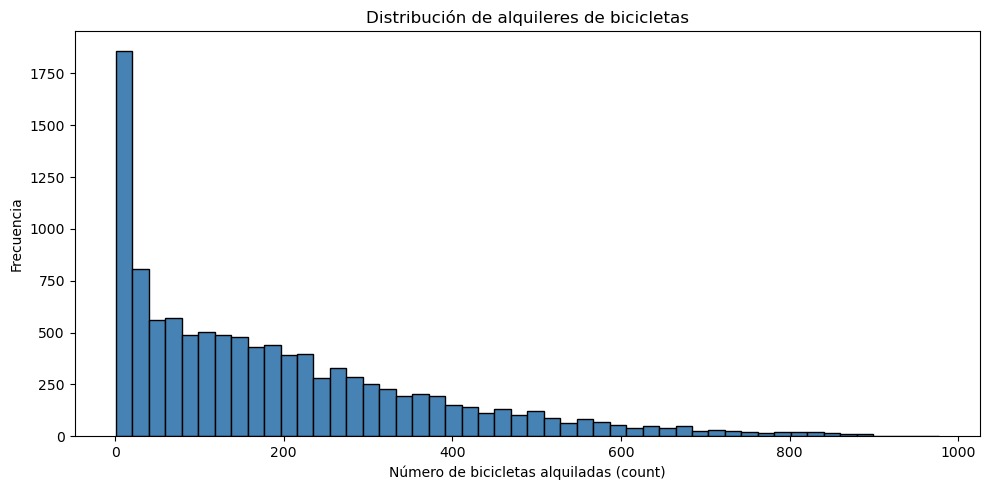

Mínimo:  1
Máximo:  977
Media:   191.57
Mediana: 145.00


In [ ]:
# ANÁLISIS EXPLORATORIO

plt.figure(figsize=(10, 5))
plt.hist(y, bins=50, color='steelblue', edgecolor='black')
plt.xlabel('Número de bicicletas alquiladas (count)')
plt.ylabel('Frecuencia')
plt.title('Distribución de alquileres de bicicletas')
plt.tight_layout()
plt.show()

print(f"Mínimo:  {y.min()}")
print(f"Máximo:  {y.max()}")
print(f"Media:   {y.mean():.2f}")
print(f"Mediana: {np.median(y):.2f}")

#Explicación:
#La distribución de alquileres de bicicletas es muy asimétrica, ya que la mayor parte de los alquileres se concentra en valores bajos de 0-200, mientras que existen algunos casos extremos con alquileres muy altos como 1000. Lo cual sugiere que casi todos los dias hay una demanda baja pero ocasionalmente hay dias con una demanda muy alta,estos valores atípicos podrian afectar el rendimiento del modelo de RLM.

In [ ]:
# NORMALIZACIÓN DE CARACTERÍSTICAS
def  featureNormalize(X):

    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [ ]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)

print(X)
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_norm)

[[ 1.      0.      0.     ... 81.      0.      0.    ]
 [ 1.      0.      0.     ... 80.      0.      1.    ]
 [ 1.      0.      0.     ... 80.      0.      2.    ]
 ...
 [ 4.      0.      1.     ... 61.     15.0013 21.    ]
 [ 4.      0.      1.     ... 61.      6.0032 22.    ]
 [ 4.      0.      1.     ... 66.      8.9981 23.    ]]
Media calculada: [2.50661400e+00 2.85688040e-02 6.80874518e-01 1.41842734e+00
 2.02308598e+01 2.36550841e+01 6.18864597e+01 1.27993954e+01
 1.15416131e+01]
Desviación estandar calculada: [ 1.11612304  0.1665912   0.46613776  0.63380947  7.79123196  8.47421137
 19.24414932  8.16416232  6.91552031]
[[-1.34986372 -0.17149048 -1.46067232 ...  0.99321305 -1.56775367
  -1.66894356]
 [-1.34986372 -0.17149048 -1.46067232 ...  0.94124921 -1.56775367
  -1.52434128]
 [-1.34986372 -0.17149048 -1.46067232 ...  0.94124921 -1.56775367
  -1.379739  ]
 ...
 [ 1.33801198 -0.17149048  0.68461625 ... -0.04606385  0.26970368
   1.36770431]
 [ 1.33801198 -0.17149048  0.68461625

In [13]:
# Añade el termino de interseccion a X
# (Columna de unos para X0)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

In [14]:
print(X)

[[ 1.         -1.34986372 -0.17149048 ...  0.99321305 -1.56775367
  -1.66894356]
 [ 1.         -1.34986372 -0.17149048 ...  0.94124921 -1.56775367
  -1.52434128]
 [ 1.         -1.34986372 -0.17149048 ...  0.94124921 -1.56775367
  -1.379739  ]
 ...
 [ 1.          1.33801198 -0.17149048 ... -0.04606385  0.26970368
   1.36770431]
 [ 1.          1.33801198 -0.17149048 ... -0.04606385 -0.83244247
   1.51230659]
 [ 1.          1.33801198 -0.17149048 ...  0.21375537 -0.46560752
   1.65690887]]


In [ ]:
#Función de costo para rml
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    # h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J

In [ ]:
#Función de descenso por el gradiente para rml
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente

    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

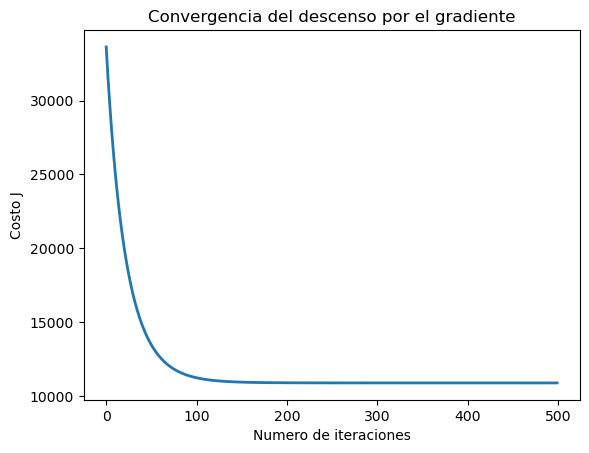

In [23]:
# ENTRENAMIENTO
alpha = 0.02
num_iters = 500

# Inicializa theta (1 bias + 9 features)
theta = np.zeros(10)

# Ejecuta el descenso por el gradiente
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del descenso por el gradiente')
pyplot.show()



In [ ]:
#PREDICCIONES
# 5 ejemplos de horas con diferentes condiciones
ejemplos = [
    # [bias, season, holiday, workingday, weather, temp, atemp, humidity, windspeed, hour]
    [1, 2, 0, 1, 1, 28, 31, 55, 10, 8],   # verano, día laboral, mañana, buen clima
    [1, 1, 0, 1, 2, 10, 12, 75, 20, 17],  # primavera, día laboral, tarde, nublado
    [1, 3, 1, 0, 1, 22, 25, 60, 8,  14],  # otoño, feriado, mediodía, buen clima
    [1, 4, 0, 0, 3, 5,  6,  90, 30, 2],   # invierno, fin de semana, madrugada, lluvia
    [1, 2, 0, 1, 1, 30, 33, 45, 5,  18],  # verano, día laboral, hora pico, buen clima
]

print("=" * 60)
print(f"{'Ejemplo':>8} {'Condición':>25} {'Predicción':>12}")
print("=" * 60)

condiciones = [
    'Verano mañana laboral',
    'Primavera tarde nublado',
    'Otoño feriado mediodía',
    'Invierno madrugada lluvia',
    'Verano hora pico laboral'
]

for i, (ejemplo, condicion) in enumerate(zip(ejemplos, condiciones)):
    X_array = np.array(ejemplo, dtype=float)
    X_array[1:] = (X_array[1:] - mu) / sigma
    pred = max(0,np.dot(X_array, theta))
    print(f"{i+1:>8} {condicion:>25} {pred:>10.0f} bicicletas")

print("=" * 60)


 Ejemplo                 Condición   Predicción
       1     Verano mañana laboral        221 bicicletas
       2   Primavera tarde nublado         98 bicicletas
       3    Otoño feriado mediodía        227 bicicletas
       4 Invierno madrugada lluvia          0 bicicletas
       5  Verano hora pico laboral        331 bicicletas
